# **Modeling & Evaluation**

# Modeling

The objective of this phase is to build a classification model capable of predicting whether a hotel booking will be canceled.

Since the target variable (`is_canceled`) contains two categories (0 and 1), this problem is treated as a binary classification task.

Two classification models were implemented:

1. Logistic Regression
2. Decision Tree Classifier

The models were evaluated using Accuracy, Precision, Recall, and Confusion Matrix.

In [73]:
import pandas as pd
df = pd.read_csv(r"C:\Users\user\OneDrive\Desktop\Machine Learning Project\Data\hotel_bookings_feature_engineered.csv")


In [74]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,total_guests,total_nights,is_family,customer_history
0,1,0,7,2015,7,27,1,0,1,1,...,0,0,0,0,0,0,1.0,1,0,0
1,1,0,13,2015,7,27,1,0,1,1,...,0,0,0,0,0,0,1.0,1,0,0
2,1,0,14,2015,7,27,1,0,2,2,...,0,0,0,0,0,0,2.0,2,0,0
3,1,0,0,2015,7,27,1,0,2,2,...,0,0,0,0,0,0,2.0,2,0,0
4,1,0,9,2015,7,27,1,0,2,2,...,0,0,0,0,0,0,2.0,2,0,0


In [75]:
df.shape

(82479, 62)

# **Remove leakage columns**

In [76]:
print(X_train.select_dtypes(include=['object']).columns)
print(X_train.select_dtypes(exclude=['int64', 'float64']).columns)
X_train.dtypes


df.drop(columns=['reservation_status','reservation_status_date'],inplace=True,errors='ignore')

Index([], dtype='str')
Index([], dtype='str')


## **Data Leakage Prevention**

During model development, the features `reservation_status_date`,`reservation_status`
were removed before training.

These variables are derived from reservation outcomes and could
provide information that would not be available at the time of
prediction.

Removing these features helps prevent data leakage and ensures
that model performance reflects real-world predictive capability.

# **Features and target**

In [77]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

## **Prepare Data**

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **Scale Features**

In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Logistic Regression**

## Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

It estimates the probability that a booking belongs to a specific class and is commonly used because it is simple, interpretable, and effective for classification tasks.

# **Train Model**

In [80]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score

)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1_score = f1_score(y_test, lr_pred)


print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("f1_score :",lr_f1_score)

Accuracy : 0.7846750727449079
Precision: 0.6773923944839114
Recall   : 0.3683253805953192
f1_score : 0.4771857521342361


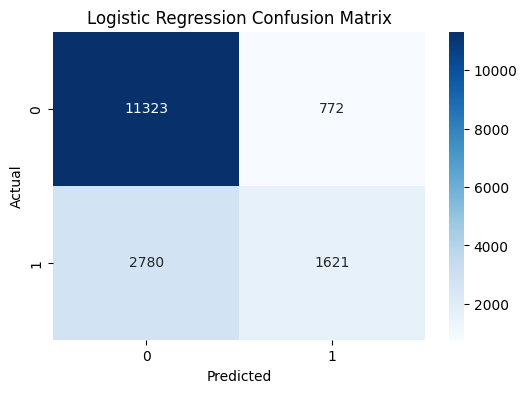

In [82]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Logistic Regression Confusion Matrix Analysis

The confusion matrix illustrates the classification performance of the **Logistic Regression** model by comparing actual values with predicted values.

## True Negatives (TN)

The model correctly predicted **11,323** instances as class **0**. This high value indicates that the model is highly effective at identifying non-positive cases.

## False Positives (FP)

There are **772** instances where the model incorrectly predicted class **1** when the actual class was **0**. The relatively low number of false positives contributes to the model's strong precision.

## False Negatives (FN)

The model incorrectly classified **2,780** actual positive cases as class **0**. This higher number of false negatives suggests that the model misses a considerable portion of positive cases.

## True Positives (TP)

The model correctly identified **1,621** positive cases as class **1**. While the model successfully detects many positive instances, there is room for improvement in capturing a larger proportion of actual positives.

## Findings

- The model performs exceptionally well in identifying class **0** instances.
- A large number of True Negatives (11,323) contributes significantly to the overall accuracy.
- The False Positive count (772) is relatively low, indicating good precision.
- The False Negative count (2,780) is considerably higher than the True Positive count (1,621), leading to lower recall.
- The model is more effective at recognizing negative cases than positive cases.

## Conclusion

The Logistic Regression model demonstrates strong overall classification performance, particularly in identifying non-positive cases. However, the relatively high number of False Negatives indicates that the model misses a significant number of actual positive instances. This suggests that while the model achieves good accuracy and precision, improvements may be needed to enhance recall and better identify positive cases.

# **Decision Tree (Bonus)**

## Decision Tree Classifier

Decision Trees classify observations by learning a series of decision rules from the data.

Unlike Logistic Regression, Decision Trees can capture non-linear relationships between variables and the target variable.

# **Train Model**

In [83]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

## **Evaluate Decision Tree**

In [84]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1_score =f1_score(y_test, dt_pred)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("f1_score :", dt_f1_score)

Accuracy : 0.7944956353055286
Precision: 0.6807293528780837
Recall   : 0.4326289479663713
f1_score : 0.5290358432898027


## **Confusion Matrix**

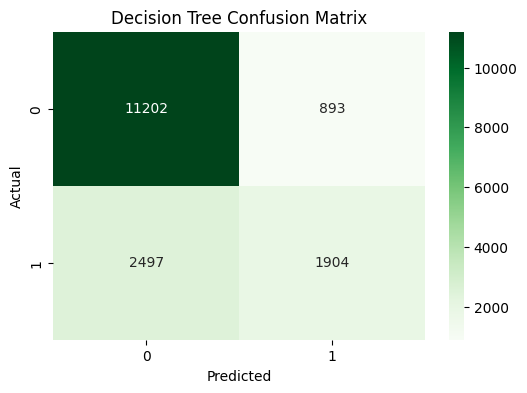

In [85]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Decision Tree Confusion Matrix Analysis

The confusion matrix presents the classification results of the **Decision Tree** model by comparing actual values with predicted values.

## True Negatives (TN)

The model correctly classified **11,202** instances as class **0**. This large number indicates that the model performs very well in identifying negative cases.

## False Positives (FP)

There are **893** instances where the model incorrectly predicted class **1** when the actual class was **0**. Although slightly higher than Logistic Regression, the false positive count remains relatively low compared to the total number of predictions.

## False Negatives (FN)

The model incorrectly classified **2,497** actual positive cases as class **0**. This indicates that some positive cases were missed, but the number of false negatives is lower than that of the Logistic Regression model.

## True Positives (TP)

The model correctly identified **1,904** positive cases as class **1**. This higher true positive count demonstrates the model's improved ability to detect positive instances.

## Findings

- The model accurately identifies a large number of class **0** instances, contributing to strong overall performance.
- The True Positive count (1,904) is higher than that of the Logistic Regression model.
- The False Negative count (2,497) is lower, indicating better detection of positive cases.
- The model achieves improved recall by correctly identifying more actual positive instances.
- Although False Positives (893) are slightly higher, the trade-off results in better overall classification effectiveness.

## Conclusion

The Decision Tree model demonstrates strong classification performance with a high number of correctly classified instances. Compared to Logistic Regression, it identifies more positive cases and produces fewer false negatives, resulting in improved recall. These results suggest that the Decision Tree model is more effective at detecting positive outcomes while maintaining competitive overall accuracy.

# **Model Comparison**

In [90]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [lr_accuracy, dt_accuracy],
    'Precision': [lr_precision, dt_precision],
    'Recall': [lr_recall, dt_recall],
    'F1_score': [lr_f1_score,dt_f1_score]
})

comparison

,Model,Accuracy,Precision,Recall,F1_score
0,Logistic Regression,0.784675,0.677392,0.368325,0.477186
1,Decision Tree,0.794496,0.680729,0.432629,0.529036


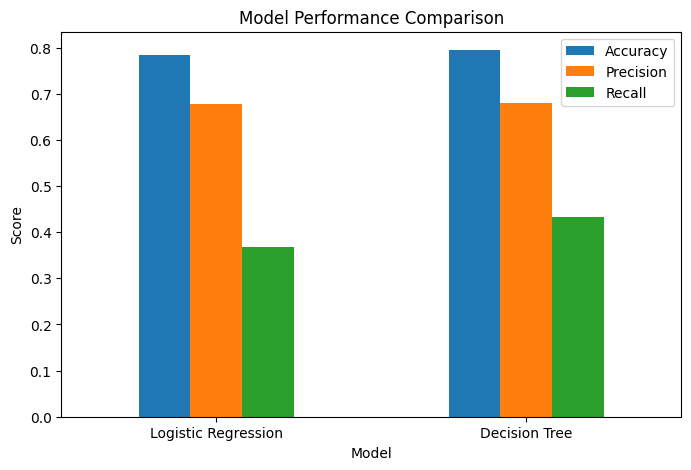

In [87]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)

plt.show()

# Model Performance Comparison

The chart compares the performance of **Logistic Regression** and **Decision Tree** models using three evaluation metrics: **Accuracy, Precision, and Recall**.

## Accuracy

Accuracy measures the overall percentage of correct predictions made by the model. Both models achieved strong accuracy scores, with the **Decision Tree** model slightly outperforming **Logistic Regression**, indicating better overall classification performance.

## Precision

Precision evaluates how many of the instances predicted as positive were actually positive. Both models show nearly identical precision values, suggesting similar effectiveness in reducing false positive predictions.

## Recall

Recall measures the model's ability to correctly identify actual positive cases. The **Decision Tree** model achieved a higher recall score than **Logistic Regression**, demonstrating a better ability to capture positive instances and minimize false negatives.

## Findings

- Decision Tree achieved the highest accuracy among the compared models.
- Precision scores are almost the same for both models.
- Decision Tree shows a noticeable improvement in recall compared to Logistic Regression.
- Higher recall indicates that the Decision Tree is more effective at identifying positive cases.
- Logistic Regression provides competitive performance while maintaining model simplicity and interpretability.

## Conclusion

Based on the comparison of Accuracy, Precision, and Recall, the **Decision Tree** model demonstrates slightly better overall performance than **Logistic Regression**. Its higher recall and accuracy suggest it is more effective for this classification task, while Logistic Regression remains a reliable and interpretable baseline model.

# Final Conclusion

The objective of this project was to develop a machine learning model capable of predicting hotel booking cancellations using historical booking data.

Before model training, data leakage was prevented by removing the variables `reservation_status` and `reservation_status_date`, ensuring that only information available at the time of booking was used for prediction. The dataset was then divided into training and testing sets, and appropriate preprocessing techniques were applied.

Two classification algorithms were evaluated:

- Logistic Regression
- Decision Tree Classifier

The Logistic Regression model achieved an accuracy of approximately **78.47%**, while the Decision Tree model achieved a slightly higher accuracy of **79.45%**. Although both models produced similar precision scores, the Decision Tree demonstrated a higher recall and F1-score, indicating a better ability to identify actual booking cancellations.

Analysis of the confusion matrices showed that both models were effective at identifying non-cancelled bookings. However, the Decision Tree model correctly detected more cancelled bookings and produced fewer false negatives than Logistic Regression.

Overall, the **Decision Tree Classifier emerged as the better-performing model**, achieving the highest Accuracy, Recall, and F1-Score. Therefore, it is the preferred model for predicting hotel booking cancellations in this project.

These predictions can help hotel management anticipate cancellations, optimize room allocation, improve revenue planning, and implement strategies to reduce the impact of booking cancellations.

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 82479 entries, 0 to 82478
Data columns (total 60 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           82479 non-null  int64  
 1   is_canceled                     82479 non-null  int64  
 2   lead_time                       82479 non-null  int64  
 3   arrival_date_year               82479 non-null  int64  
 4   arrival_date_month              82479 non-null  int64  
 5   arrival_date_week_number        82479 non-null  int64  
 6   arrival_date_day_of_month       82479 non-null  int64  
 7   stays_in_weekend_nights         82479 non-null  int64  
 8   stays_in_week_nights            82479 non-null  int64  
 9   adults                          82479 non-null  int64  
 10  children                        82479 non-null  float64
 11  babies                          82479 non-null  int64  
 12  is_repeated_guest               82479 non-n